# Validación de Modelo — Smoking Dataset

El objetivo cargar el modelo final optimizado (Random Forest) y validar su rendimiento sobre el conjunto de prueba.
Se generarán métricas de clasificación, visualizaciones de rendimiento (Matriz de Confusión, Curva ROC) y el análisis de la importancia de las variables (Feature Importance).

In [7]:
import os
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 12
sns.set_theme(style="whitegrid")

PAL = {0: "#378ADD", 1: "#D85A30"}
SEED = 42

## 2. Carga del Modelo y Features

Cargamos el modelo `.joblib` y la lista de variables para asegurar que los datos de entrada tengan el formato correcto.

In [9]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
MODELS_DIR = os.path.join(BASE_DIR, "models")

modelo_path = os.path.join(MODELS_DIR, "modelo_final.joblib")
features_path = os.path.join(MODELS_DIR, "feature_names.joblib")

# Cargar artefactos guardados
modelo_final = joblib.load(modelo_path)
feature_names = joblib.load(features_path)

print(f"Modelo cargado correctamente: {type(modelo_final).__name__}")
print(f"Cantidad de features requeridas: {len(feature_names)}")

Modelo cargado correctamente: RandomForestClassifier
Cantidad de features requeridas: 16


## 3. Preparación de los Datos de Validación

Para validar el modelo, recreamos el mismo `train_test_split` utilizado en el entrenamiento mediante el `SEED=42`. En un entorno de producción, aquí cargarías un archivo nuevo (ej. `nuevos_datos.csv`).

In [10]:
DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "smoking_processed.csv")
df = pd.read_csv(DATA_PATH)
df["smoking"] = df["smoking"].astype(int)

# Separar X e y
X = df.drop(columns=['smoking'])
y = df["smoking"]

# Asegurar que las columnas de X estén en el mismo orden que durante el entrenamiento
X = X[feature_names]

# Recrear el split para obtener exactamente el mismo X_test e y_test
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Set de validación (Test) shape: {X_test.shape}")
print(f"Balance de clases en validación:\n{y_test.value_counts(normalize=True).round(3)}")

Set de validación (Test) shape: (9970, 16)
Balance de clases en validación:
smoking
0    0.634
1    0.366
Name: proportion, dtype: float64


## 4. Predicciones y Métricas Globales

Generamos las predicciones discretas y las probabilidades para calcular el desempeño general del modelo.

In [11]:
# Ver qué features espera el modelo vs las que tiene X_test
features_modelo = modelo_final.feature_names_in_
features_test   = X_test.columns.tolist()

print("En X_test pero NO en el modelo:")
print(set(features_test) - set(features_modelo))

print("\nEn el modelo pero NO en X_test:")
print(set(features_modelo) - set(features_test))

En X_test pero NO en el modelo:
set()

En el modelo pero NO en X_test:
set()


In [12]:
# Reordenar X_test con exactamente las columnas que espera el modelo
X_test_aligned = X_test[features_modelo]

y_pred = modelo_final.predict(X_test_aligned)
y_prob = modelo_final.predict_proba(X_test_aligned)[:, 1]
# Calcular métricas principales
f1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)

print("=== MÉTRICAS GLOBALES DEL MODELO FINAL ===")
print(f"F1-Score (Fumador): {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"Accuracy          : {acc:.4f}")
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, target_names=["No Fuma (0)", "Fuma (1)"]))

=== MÉTRICAS GLOBALES DEL MODELO FINAL ===
F1-Score (Fumador): 0.7497
ROC-AUC           : 0.8847
Accuracy          : 0.7966

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

 No Fuma (0)       0.89      0.78      0.83      6324
    Fuma (1)       0.68      0.83      0.75      3646

    accuracy                           0.80      9970
   macro avg       0.79      0.80      0.79      9970
weighted avg       0.81      0.80      0.80      9970



## 5. Visualizaciones de Rendimiento

Analizamos visualmente el desempeño mediante la Matriz de Confusión y la Curva ROC.

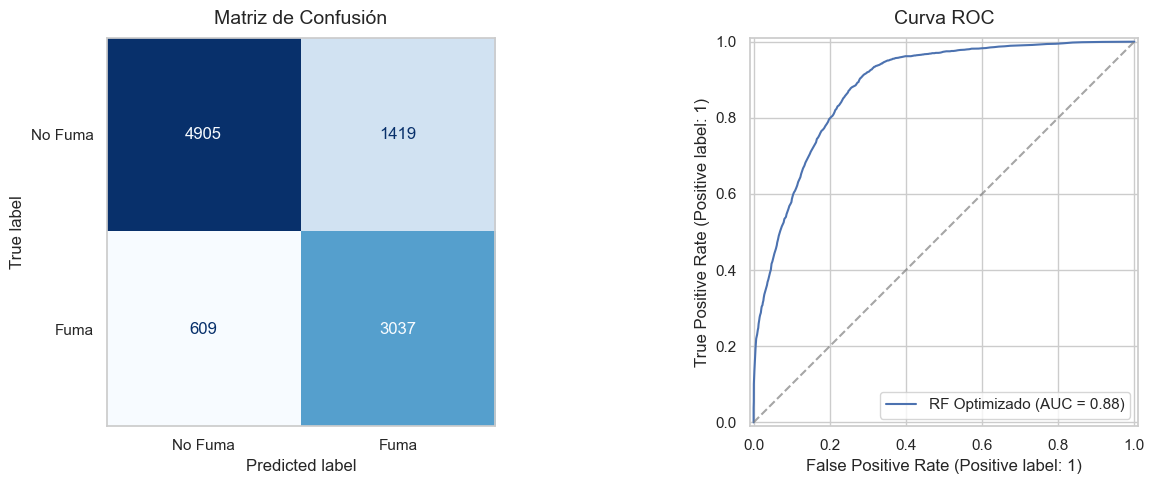

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Fuma", "Fuma"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Matriz de Confusión", fontsize=14, pad=10)
axes[0].grid(False)

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob, name="RF Optimizado", ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7)
axes[1].set_title("Curva ROC", fontsize=14, pad=10)

plt.tight_layout()
plt.show()

## 6. Importancia de Variables (Feature Importance)

Dado que nuestro modelo final es un Random Forest, podemos extraer e interpretar el peso que tiene cada variable en la toma de decisión (Impureza de Gini).

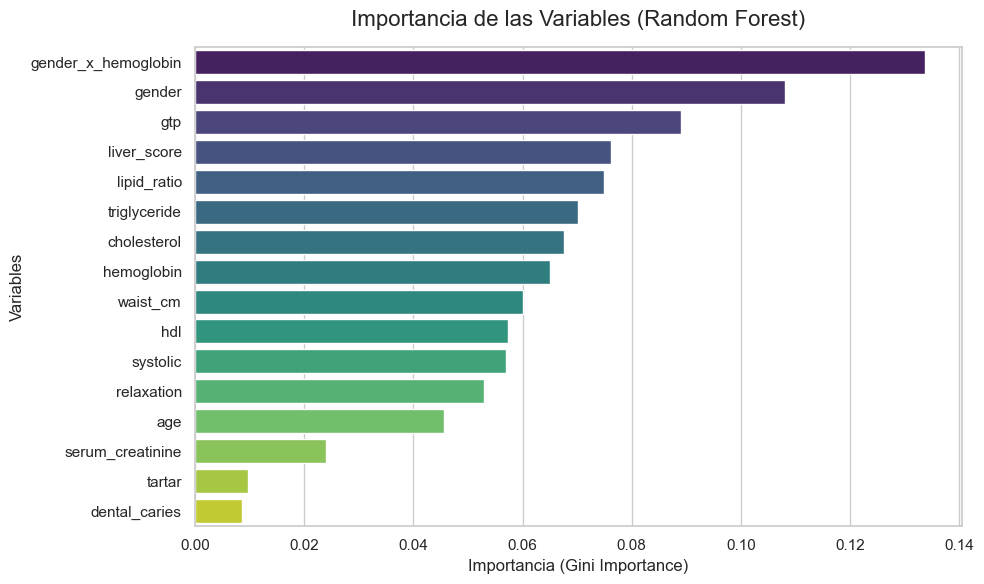

In [15]:
# Extraer la importancia de las variables
importancias = modelo_final.feature_importances_

# Crear un DataFrame para facilitar el gráfico
df_importancias = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importancias
}).sort_values(by="Importance", ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancias, 
    x="Importance", 
    y="Feature", 
    palette="viridis"
)
plt.title("Importancia de las Variables (Random Forest)", fontsize=16, pad=15)
plt.xlabel("Importancia (Gini Importance)", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.tight_layout()
plt.show()